**Flux Plots for Different Deployments**

This will try to visualize flux on frying pan shoals over the five deployments.


In [18]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
from spectral_sediment import despiker, tidal_ellipse
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
plt.rcParams.update({'font.size': 14}) 


deployment_num = [1,2,3,4,5]
sensor_spot = ["S"]
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

ImportError: cannot import name 'tidal_ellipse' from 'spectral_sediment' (C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts\spectral_sediment.py)

In [2]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            files = ["DepthAveragedFlowDirection", "DepthAveragedCurrentVelocity", "Vertavg","Echo1avg","Time","Sedtime","DepthAveragedEastVelocity","DepthAveragedNorthVelocity"]
            waves = {}
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                print(file_name)
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location}_{dep}"] = waves

Processing S0...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Vertavg
Echo1avg
Time
Sedtime
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S1...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Vertavg
Echo1avg
Time
Sedtime
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S0...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Vertavg
Echo1avg
Time
Sedtime
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S1...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Vertavg
Echo1avg
Time
Sedtime
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S0...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Vertavg
Echo1avg
Time
Sedtime
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S1...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Vertavg
Echo1avg
Time
Sedtime
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S1...
DepthAveragedFlowDirection
DepthAveragedCurrent

In [3]:
#Create lists of what sensors are in each deployment
# 1. Define your categories based on your naming convention
sides = ['S', 'E', 'C']  # South, East, Central
landers = ['0', '1']
deployments = range(1, 6)

# 2. Organize variables into a nested dictionary
# This uses globals() to grab the actual data stored in those variable names
organized_waves = {}

for s in sides:
    for l in landers:
        for d in deployments:
            var_name = f"waves_{s}{l}_{d}"
            
            # Check if this specific combination exists in your workspace
            if var_name in globals():
                if s not in organized_waves: organized_waves[s] = {}
                if l not in organized_waves[s]: organized_waves[s][l] = {}
                
                # Store the data in the dict
                organized_waves[s][l][d] = globals()[var_name]

# Example automative loop 
# for side, lander_dict in organized_waves.items():
#     for lander_id, dep_dict in lander_dict.items():
#         for dep_num, data in dep_dict.items():
print(organized_waves.keys())

dict_keys(['S'])


In [4]:
#Function to convert unix timestamp in ns to regular datetime in UTC
print(organized_waves['S']['0'][1]['Time'].values.squeeze()[0])  # Example of a timestamp in ns

2024-08-21T11:30:00.126107


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def plot_orbital_bars(waves, title=None, cmap="viridis"):
    plt.rcParams.update({'font.size': 7}) 

    """
    Polar orbital bar plot.

    Parameters
    ----------
    waves : dict
        Dictionary with keys:
        - DepthAveragedFlowDirection
        - DepthAveragedCurrentVelocity
        - Vertavg

    title : str
        Plot title

    cmap : str
        Matplotlib colormap

    normalize_velocity : bool
        Normalize bar length
    """

    # ----------------------------------
    # Extract data
    # ----------------------------------
    #Check if echosounder contains data
    echo = waves["Echo1avg"].empty
    print(f"Echo data empty: {echo}")

    direction = waves["DepthAveragedFlowDirection"].values.squeeze()
    velocity = waves["DepthAveragedCurrentVelocity"].values.squeeze()
    if echo ==True:
        vertavg, mask = despiker(waves["Vertavg"])
    if echo ==False:
        vertavg, mask = despiker(waves["Echo1avg"])
    #Downsample vert avg to match dir and vel length

    if len(vertavg) > len(direction):
        chunks = np.array_split(vertavg, len(direction))
        
        # Map the mean function across those chunks
        vertavg = np.array([np.mean(chunk) for chunk in chunks])

    # ----------------------------------
    # Bin Data into 10 degree bins
    # ----------------------------------
    bins = np.arange(0, 360 + 10, 10)
    bin_indices = np.digitize(direction, bins) - 1  # Get bin
    bin_vertavg = np.array([np.nansum(vertavg[bin_indices == i]) for i in range(len(bins) - 1)])
    bin_theta = np.deg2rad((bins[:-1] + bins[1:]) / 2)  # Bin centers
    bin_width = np.deg2rad(10)  # Bin width
    bin_vel = np.array([np.nanmean(velocity[bin_indices == i]) for i in range(len(bins) - 1)])
    
    bin_vel = np.nan_to_num(bin_vel, nan=0.0)

    # Normalize intensity for color mapping
    bin_vertavg = bin_vertavg / np.nanmax(bin_vertavg)

    # ----------------------------------
    # Colors from Vertavg
    # ----------------------------------

    norm = plt.Normalize(np.nanmin(bin_vertavg), np.nanmax(bin_vertavg))
    cmap = plt.colormaps.get_cmap(cmap)
    colors = cmap(norm(bin_vertavg))

    

    # ----------------------------------
    # Plot
    # ----------------------------------
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(4, 4))

    bars = ax.bar(bin_theta, bin_vel, width=bin_width, bottom=0, color=colors, alpha=0.8)
    ax.set_ylim(0,.5)
    
    # ----------------------------------
    # Formatting
    # ----------------------------------

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    if title:
        ax.set_title(title)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    plt.colorbar(sm, ax=ax, label="Normalized Sum of Backscatter Intensity (dB)")
    plt.xlabel("Flow Direction (degrees)")
    plt.ylabel("Depth-Averaged Current Velocity (m/s)", labelpad=40)
    plt.tight_layout()
    plt.show()

In [6]:
#generate quiver plots

def plot_quiver_ampavg(waves, title=None,echo = False, ylim1 = 30, ylim2 = 80):
    plt.rcParams.update({'font.size': 14}) 
    #Check if echosounder contains data
    echo = waves["Echo1avg"].empty
    print(f"Echo data empty: {echo}")
    
    fig,axs = plt.subplots(2, 1, figsize=(14,6), sharex=True)
    v = waves["DepthAveragedCurrentVelocity"].values.squeeze() * np.cos(np.deg2rad(waves["DepthAveragedFlowDirection"].values.squeeze()))
    u = waves["DepthAveragedCurrentVelocity"].values.squeeze() * np.sin(np.deg2rad(waves["DepthAveragedFlowDirection"].values.squeeze()))

    x = waves['Time'].values.squeeze()
    y = np.zeros(x.shape)  # x can be zeros since we are only interested in the direction and magnitude of the vectors

    q = axs[0].quiver(x,y,u,v,waves['DepthAveragedCurrentVelocity'].values.squeeze(), cmap='viridis',scale =7)
    axs[0].quiverkey(q, X=0.9, Y=1.05, U=0.5, label='0.5 m/s', labelpos='E',)
    axs[0].set_title(title + " Current Flow Vectors")
    axs[0].set_xlabel("Time (YY-MM-DD)")
    axs[0].set_ylabel("(South to North)")
    axs[0].set_xlim(waves['Time'].values.squeeze()[0], waves['Time'].values.squeeze()[-24*2])

    if echo == True:
        despiked_vert, mask = despiker(waves["Vertavg"],lam =3)

        axs[1].plot(waves['Sedtime'].values.squeeze(), despiked_vert,label= 'Vertical Depth Averaged Amplitude')
        axs[1].set_xlabel("Time (YY-MM-DD)")
        axs[1].set_ylabel("Backscatter Intensity (dB)")
        axs[1].set_title(title + " Backscatter Intensity")
        axs[1].set_ylim(ylim1,ylim2) 
        axs[1].legend()

    if echo == False:
        despiked_echo, mask = despiker(waves["Echo1avg"], lam = 3)

        axs[1].plot(waves['Sedtime'].values.squeeze(), despiked_echo,label= 'Echo 1 Depth Averaged Amplitude')
        axs[1].set_xlabel("Time (YY-MM-DD)")
        axs[1].set_ylabel("Backscatter Intensity (dB)")
        axs[1].set_title(title + " Backscatter Intensity")
        axs[1].set_ylim(ylim1, ylim2)
        axs[1].legend()

    axs[0].tick_params(labelbottom=True,labelrotation = 15)
    axs[1].tick_params(labelbottom=True,labelrotation = 15)
    plt.tight_layout()
    plt.show()

**Section to look at Different plots**

Echo data empty: True


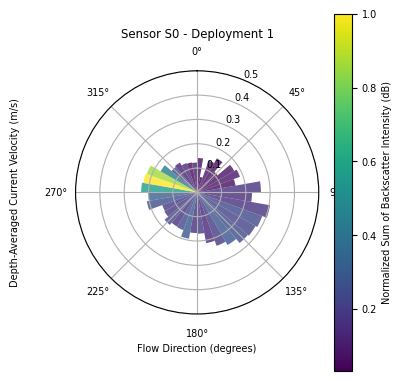

Echo data empty: True


C:\Users\lwlav\AppData\Local\Temp\ipykernel_99644\2129345367.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\lwlav\anaconda3\envs\boemenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


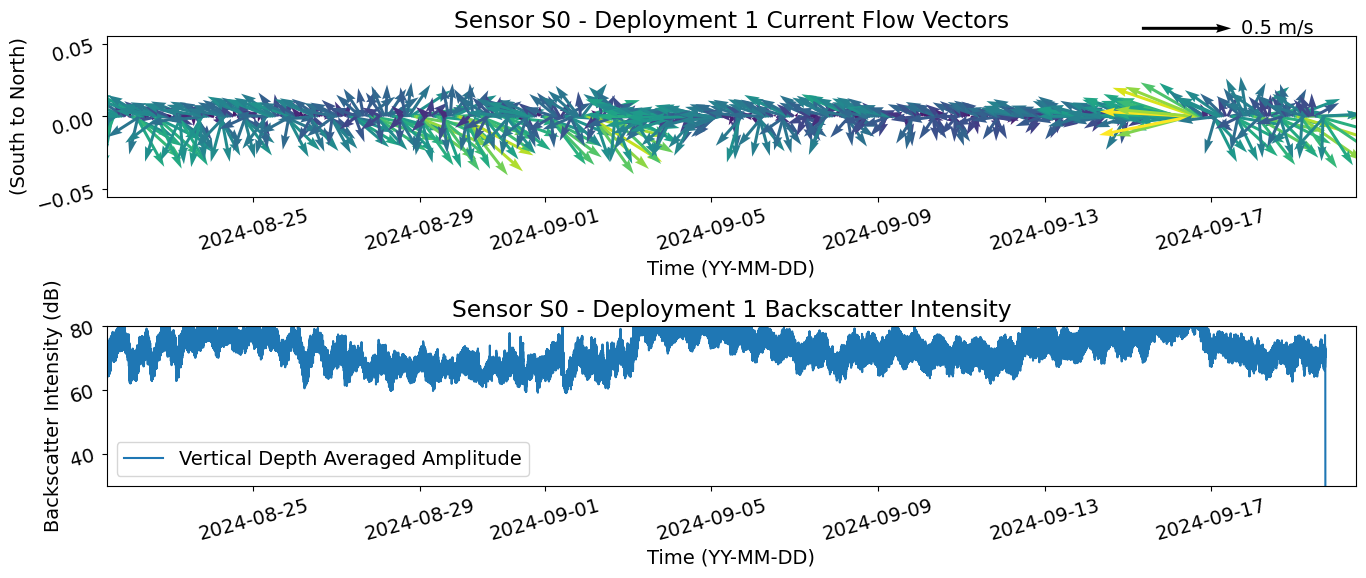

In [7]:
plot_orbital_bars(organized_waves['S']['0'][1], title="Sensor S0 - Deployment 1")
plot_quiver_ampavg(organized_waves['S']['0'][1], title="Sensor S0 - Deployment 1")

Deployment 1 has **TC8**, S0 Lander features strong SSW currents when echo intensity is peaking

Echo data empty: True


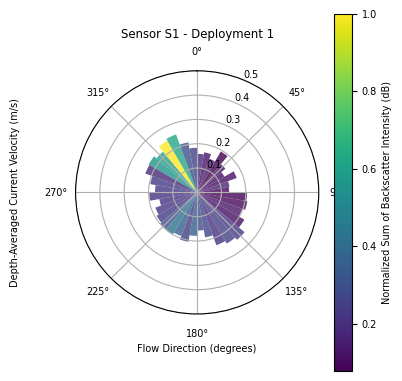

Echo data empty: True


C:\Users\lwlav\AppData\Local\Temp\ipykernel_99644\2129345367.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\lwlav\anaconda3\envs\boemenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


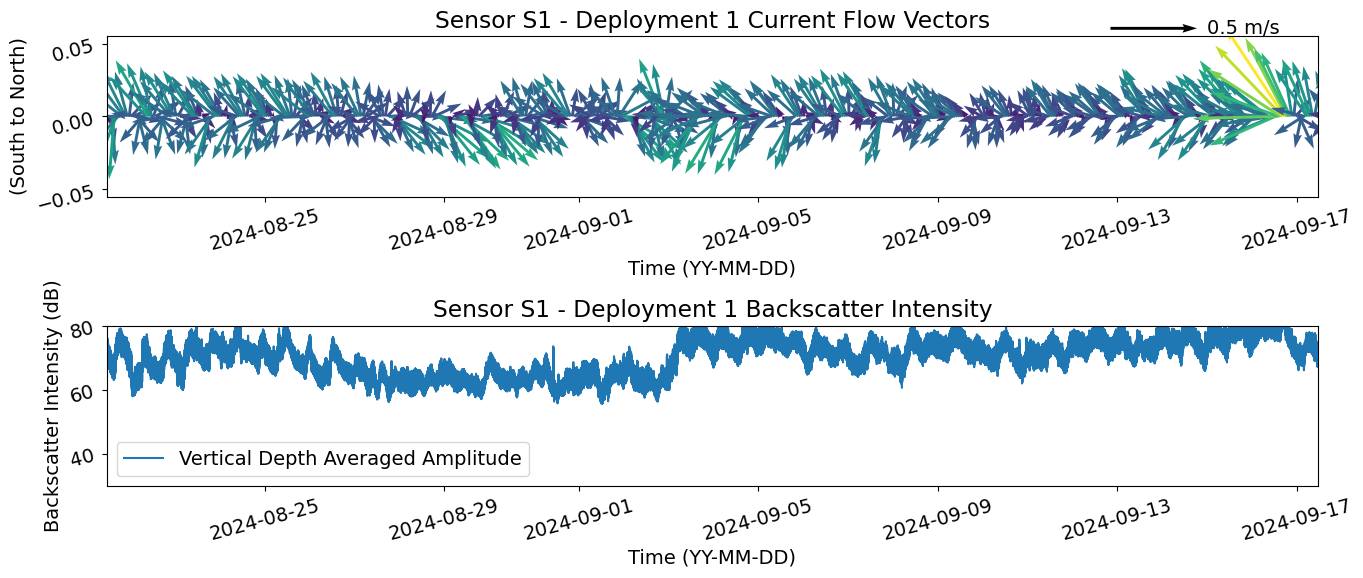

In [8]:
plot_orbital_bars(organized_waves['S']['1'][1], title="Sensor S1 - Deployment 1")
plot_quiver_ampavg(organized_waves['S']['1'][1], title="Sensor S1 - Deployment 1")

Deployment 1 has **TC8**, S1 Lander features strong WSW currents when echo intensity is peaking. 

Echo data empty: True


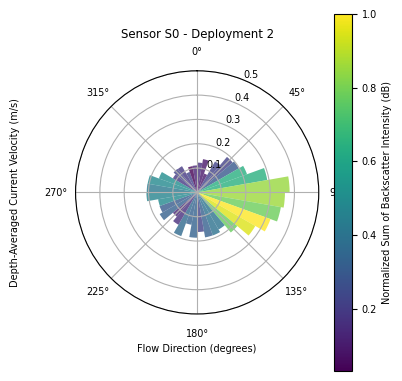

Echo data empty: True


C:\Users\lwlav\AppData\Local\Temp\ipykernel_99644\2129345367.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


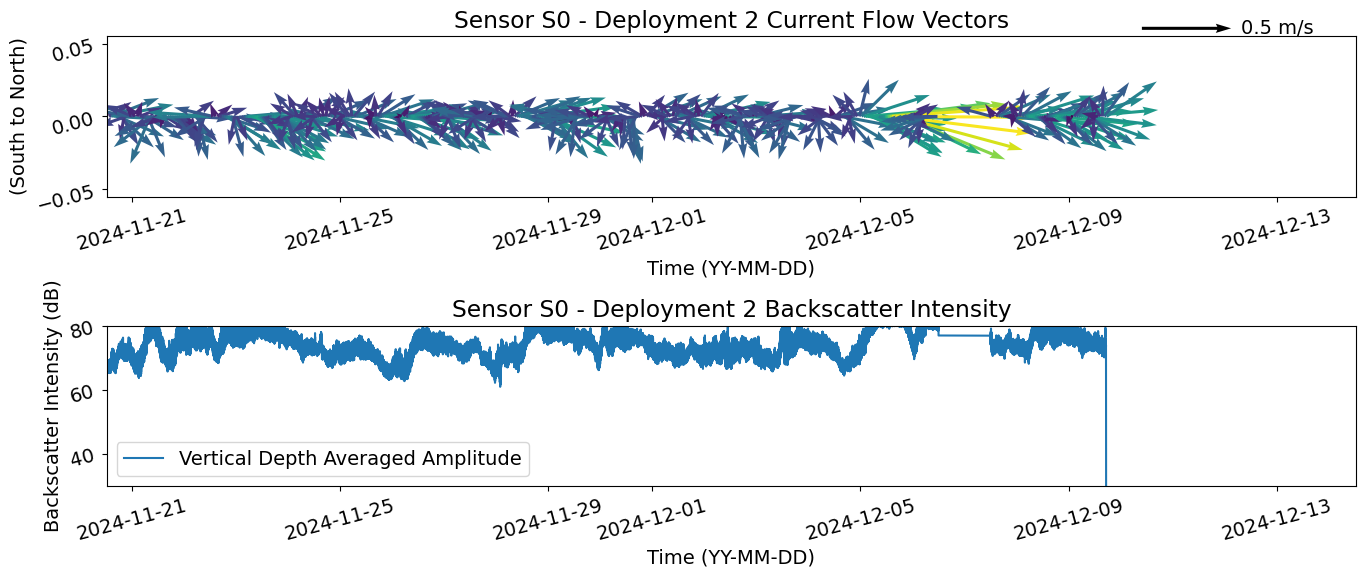

In [9]:
plot_orbital_bars(organized_waves['S']['0'][2], title="Sensor S0 - Deployment 2")
plot_quiver_ampavg(organized_waves['S']['0'][2], title="Sensor S0 - Deployment 2")

Deployment 2 has **Small Nor'easters**, S0 Lander features weak N currents when echo intensity is peaking, likely due to tides.

Echo data empty: True


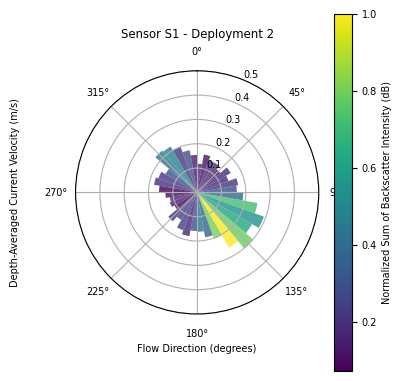

Echo data empty: True


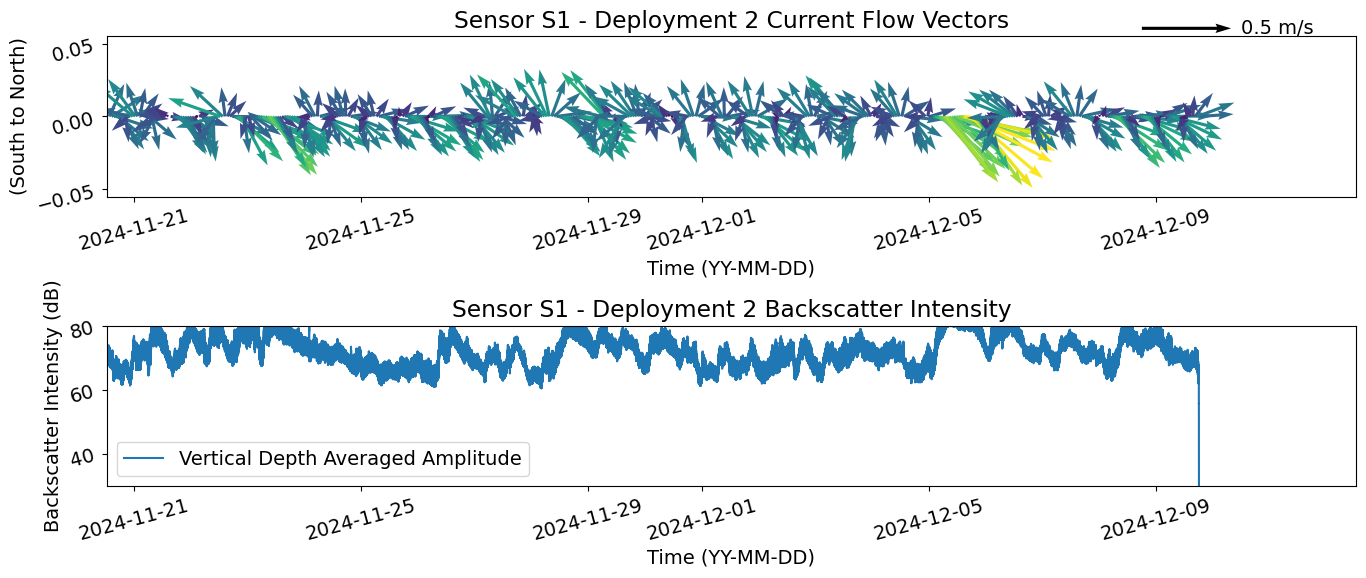

In [10]:
plot_orbital_bars(organized_waves['S']['1'][2], title="Sensor S1 - Deployment 2")
plot_quiver_ampavg(organized_waves['S']['1'][2], title="Sensor S1 - Deployment 2")

Echo data empty: True


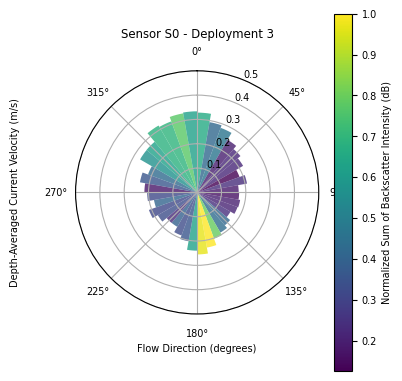

Echo data empty: True


C:\Users\lwlav\AppData\Local\Temp\ipykernel_99644\2129345367.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\lwlav\anaconda3\envs\boemenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


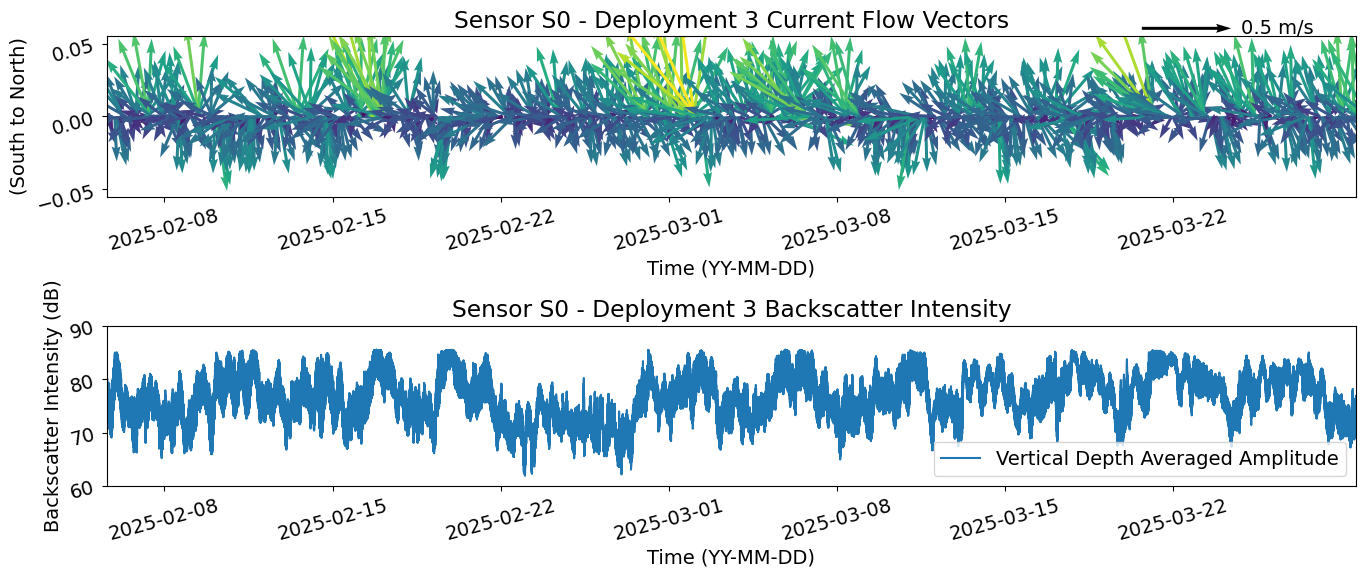

'Something wrong with this deployment, need to check data'

In [11]:
plot_orbital_bars(organized_waves['S']['0'][3], title="Sensor S0 - Deployment 3")
plot_quiver_ampavg(organized_waves['S']['0'][3], title="Sensor S0 - Deployment 3", ylim1=60,ylim2=90)
"""Something wrong with this deployment, need to check data"""


Echo data empty: True


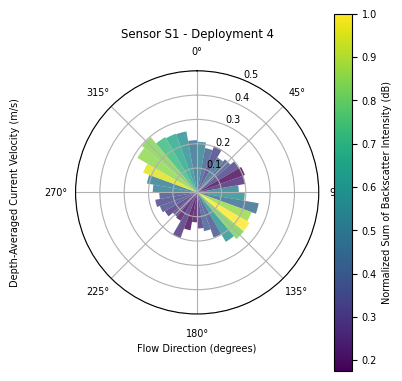

Echo data empty: True


c:\Users\lwlav\anaconda3\envs\boemenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


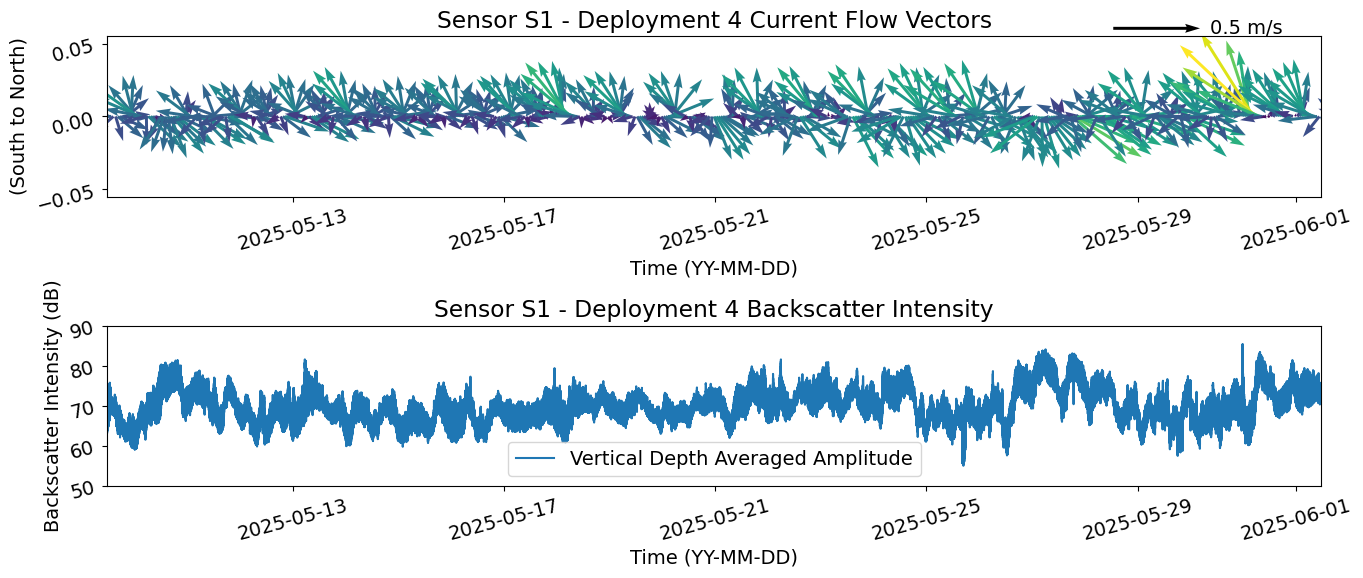

In [12]:
plot_orbital_bars(organized_waves['S']['1'][4], title="Sensor S1 - Deployment 4")
plot_quiver_ampavg(organized_waves['S']['1'][4], title="Sensor S1 - Deployment 4",ylim1=50,ylim2=90)

Echo data empty: False


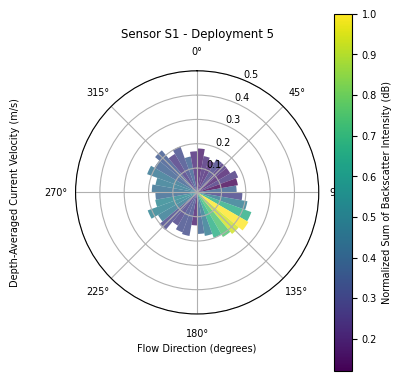

Echo data empty: False


c:\Users\lwlav\anaconda3\envs\boemenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


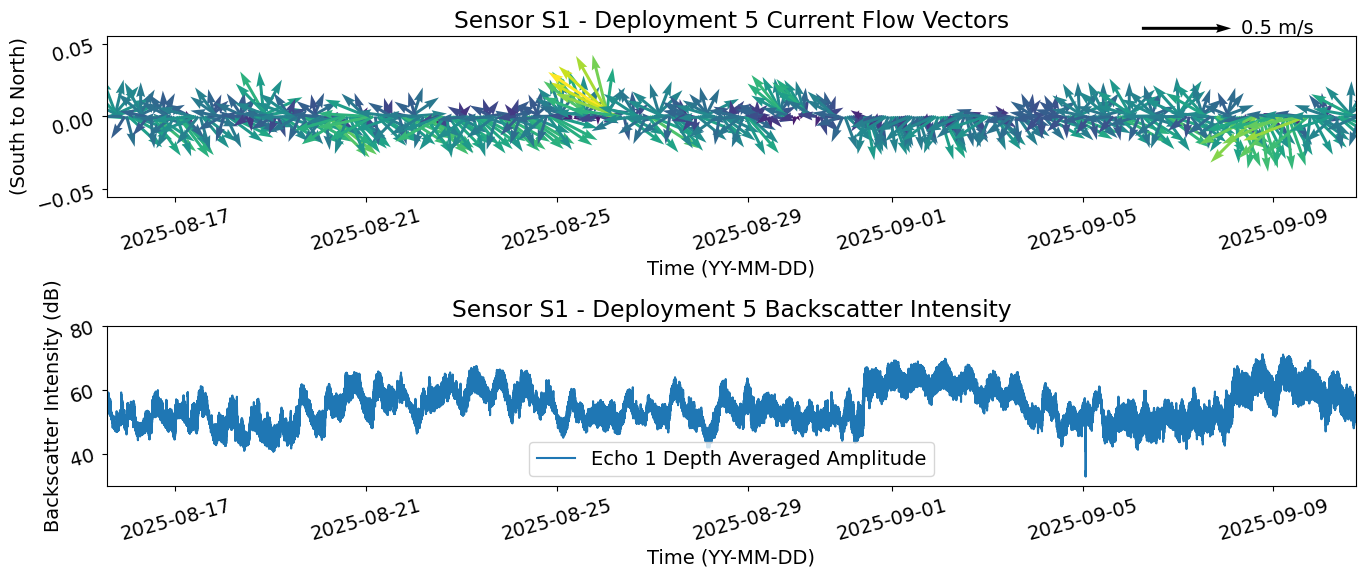

In [13]:
plot_orbital_bars(organized_waves['S']['1'][5], title="Sensor S1 - Deployment 5")
plot_quiver_ampavg(organized_waves['S']['1'][5], title="Sensor S1 - Deployment 5")

In [16]:
tidal_ellipse(organized_waves['S']['0'][1]['Time'].values.squeeze(),organized_waves['S']['0'][1]['DepthAveragedEastVelocity'].values.squeeze(), organized_waves['S']['0'][1]['DepthAveragedNorthVelocity'].values.squeeze())

NameError: name 'tidal_ellipse' is not defined

c:\Users\lwlav\anaconda3\envs\boemenv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


solve: matrix prep ... solution ... done.
prep/calcs ... done.


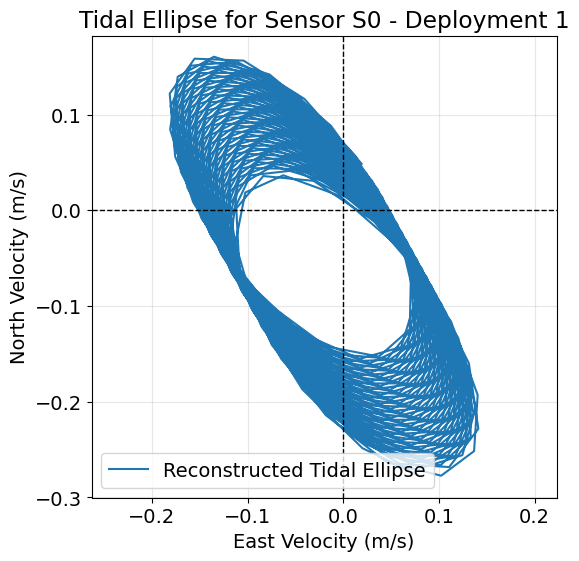

In [14]:
import utide
#Find tidal ellipses for S0 in deployment 1
t = organized_waves['S']['0'][1]['Time'].values.squeeze()
u = organized_waves['S']['0'][1]['DepthAveragedEastVelocity'].values.squeeze()
v = organized_waves['S']['0'][1]['DepthAveragedNorthVelocity'].values.squeeze()

coef = utide.solve(t, u, v, lat=33.9, method="ols", conf_int="linear", constit=['M2'])

#With coefficients, we can reconstruct the tidal signal and plot the ellipses
out = utide.reconstruct(t, coef)

# Extract the fitted velocities
u_fit = out.u
v_fit = out.v

# Plotting the ellipse
plt.figure(figsize=(6, 6))
plt.plot(v_fit,u_fit, label='Reconstructed Tidal Ellipse')
plt.axhline(0, color='black', lw=1, ls='--')
plt.axvline(0, color='black', lw=1, ls='--')
plt.xlabel("East Velocity (m/s)")
plt.ylabel("North Velocity (m/s)")
plt.title("Tidal Ellipse for Sensor S0 - Deployment 1")
plt.axis('equal') # Crucial for seeing the true shape of the ellipse
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

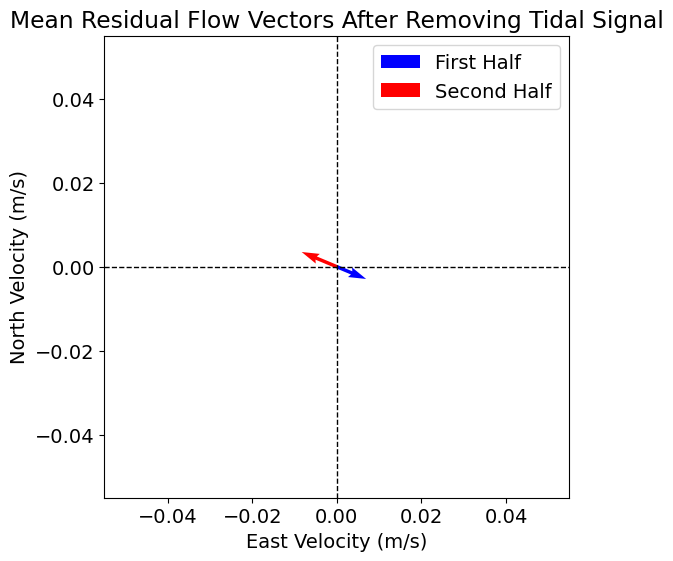

Mean residual flow vector first half: (0.007, -0.003) m/s


In [ ]:
#Remove tidal ellipse from original signal to get residuals
u_residual = u - u_fit
v_residual = v - v_fit

#Plot vector arrow of mean flwo from first hald and second half of deployment to see if there is a change in flow direction or magnitude after removing tidal signal
fig, ax = plt.subplots(figsize=(6, 6))
# First half of deployment
mean_u_first_half = np.mean(u_residual[:len(u_residual)//2])
mean_v_first_half = np.mean(v_residual[:len(v_residual)//2])
ax.quiver(0, 0, mean_u_first_half, mean_v_first_half, angles='xy', scale_units='xy', scale=1, color='blue', label='First Half')
# Second half of deployment
mean_u_second_half = np.nanmean(u_residual[len(u_residual)//2:])
mean_v_second_half = np.nanmean(v_residual[len(v_residual)//2:])
ax.quiver(0, 0, mean_u_second_half, mean_v_second_half, angles='xy', scale_units='xy', scale=1, color='red', label='Second Half')
ax.axhline(0, color='black', lw=1, ls='--')
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel("East Velocity (m/s)")
ax.set_ylabel("North Velocity (m/s)")
ax.set_title("Mean Residual Flow Vectors After Removing Tidal Signal")
ax.legend()
plt.show()

print(f"Mean residual flow vector first half: ({mean_u_first_half:.3f}, {mean_v_first_half:.3f}) m/s")
